In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [4]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
print(df.shape)
df.info()
df.describe()

(20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df = df.dropna()
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
X = df.drop(
    columns=["median_house_value"]
)
X = pd.get_dummies(
    X,
    drop_first=True
)
y = df["median_house_value"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LinearRegression()
model.fit(
    X_train,
    y_train
)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(
    y_test,
    y_pred
)
rmse = np.sqrt(mse)
mae = mean_absolute_error(
    y_test,
    y_pred
)
r2 = r2_score(
    y_test,
    y_pred
)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 4802173538.604162
RMSE: 69297.71669113032
MAE : 50413.43330810071
R²  : 0.6488402154431991


In [12]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
comparison.head(10)

,Actual,Predicted
0,245800.0,201882.959868
1,137900.0,147279.682144
2,218200.0,207796.609798
3,220800.0,180487.576722
4,170500.0,190323.923130
5,75000.0,95437.897104
6,269400.0,287156.451612
7,228900.0,257624.771805
8,500001.0,385383.556151
9,80800.0,62548.197551


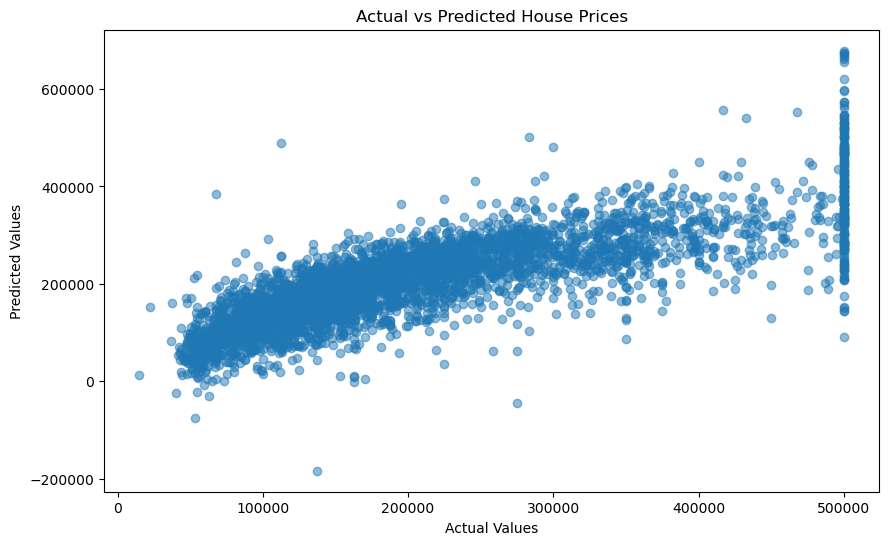

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(
    "Actual vs Predicted House Prices"
)
plt.show()

***Task 2***

In [14]:
df = pd.read_csv("housing.csv")
df = df.dropna()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [15]:
y = df["median_house_value"]

In [16]:
X_A = df[["median_income"]]
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y,
    test_size=0.2,
    random_state=42
)
model_A = LinearRegression()
model_A.fit(
    X_train_A,
    y_train_A
)
pred_A = model_A.predict(
    X_test_A
)

In [17]:
mse_A = mean_squared_error(
    y_test_A,
    pred_A
)
rmse_A = np.sqrt(mse_A)
mae_A = mean_absolute_error(
    y_test_A,
    pred_A
)
r2_A = r2_score(
    y_test_A,
    pred_A
)

In [18]:
X_B = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms"
    ]
]
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y,
    test_size=0.2,
    random_state=42
)
model_B = LinearRegression()
model_B.fit(
    X_train_B,
    y_train_B
)
pred_B = model_B.predict(
    X_test_B
)

In [19]:
mse_B = mean_squared_error(
    y_test_B,
    pred_B
)

rmse_B = np.sqrt(mse_B)

mae_B = mean_absolute_error(
    y_test_B,
    pred_B
)
r2_B = r2_score(
    y_test_B,
    pred_B
)

In [20]:
comparison = pd.DataFrame({

    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R2"
    ],

    "Model A": [
        mse_A,
        rmse_A,
        mae_A,
        r2_A
    ],

    "Model B": [
        mse_B,
        rmse_B,
        mae_B,
        r2_B
    ]
})
comparison

,Metric,Model A,Model B
0,MSE,7.221011e+09,6.649672e+09
1,RMSE,8.497653e+04,8.154552e+04
2,MAE,6.337455e+04,6.093980e+04
3,R2,4.719623e-01,5.137416e-01


In [21]:
if r2_B > r2_A:
    print("Model B performed better.")
else:
    print("Model A performed better.")

Model B performed better.


## Result

Model B performed better than Model A because it used multiple useful features for prediction.

The R² score increased while the error metrics (MSE, RMSE, and MAE) decreased.

This shows that house prices depend on multiple factors, and including additional relevant features improves the model's predictive performance.

***Task 3***

In [22]:
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("housing.csv")

df = df.dropna()

In [24]:
X = df.drop(
    columns=["median_house_value"]
)
X = pd.get_dummies(
    X,
    drop_first=True
)
y = df["median_house_value"]

In [25]:
splits = [
    0.2,
    0.3,
    0.4
]

In [26]:
results = []

for test_size in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    model = LinearRegression()

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(
        y_train,
        train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(train_mse)

    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )
    results.append([
        f"{int((1-test_size)*100)}/{int(test_size*100)}",
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_r2,
        test_r2
    ])

In [27]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Split",
        "Train MSE",
        "Test MSE",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train R2",
        "Test R2"
    ]
)
results_df

,Split,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,80/20,4.690511e+09,4.802174e+09,68487.306669,69297.716691,49549.965899,50413.433308,0.645648,0.648840
1,70/30,4.755932e+09,4.614164e+09,68963.264247,67927.638042,49868.110942,49642.998352,0.642988,0.653875
2,60/40,4.830748e+09,4.542710e+09,69503.581985,67399.626349,50136.605216,49604.344754,0.640559,0.654580


In [28]:
results_df["R2 Gap"] = (
    results_df["Train R2"]
    -
    results_df["Test R2"]
)
results_df

,Split,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,R2 Gap
0,80/20,4.690511e+09,4.802174e+09,68487.306669,69297.716691,49549.965899,50413.433308,0.645648,0.648840,-0.003192
1,70/30,4.755932e+09,4.614164e+09,68963.264247,67927.638042,49868.110942,49642.998352,0.642988,0.653875,-0.010887
2,60/40,4.830748e+09,4.542710e+09,69503.581985,67399.626349,50136.605216,49604.344754,0.640559,0.654580,-0.014020


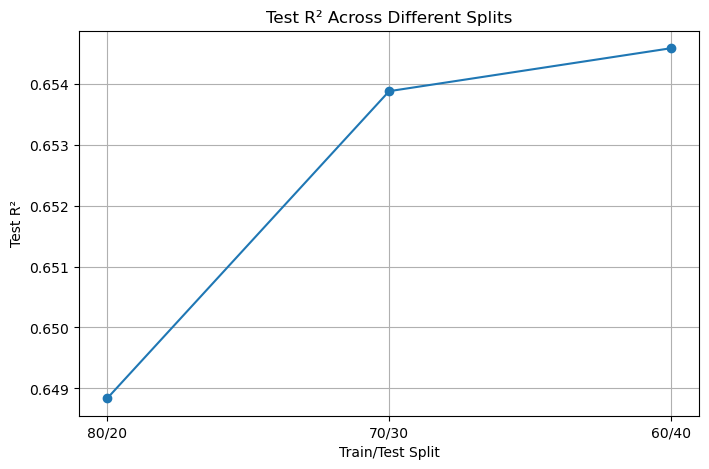

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Split"],
    results_df["Test R2"],
    marker="o"
)

plt.title(
    "Test R² Across Different Splits"
)
plt.xlabel("Train/Test Split")
plt.ylabel("Test R²")
plt.grid()
plt.show()

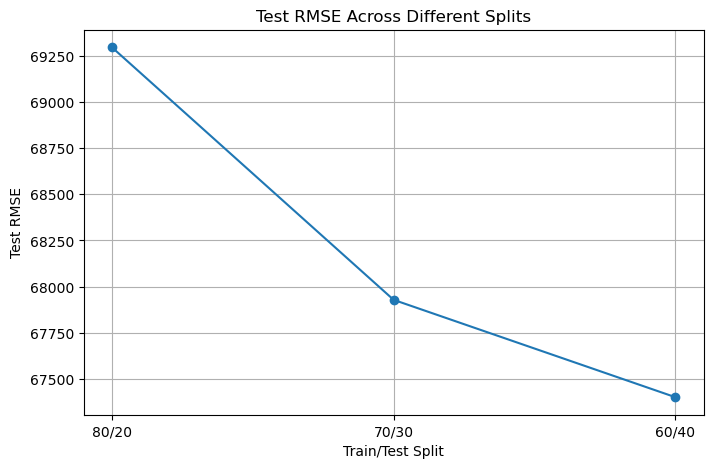

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Split"],
    results_df["Test RMSE"],
    marker="o"
)

plt.title(
    "Test RMSE Across Different Splits"
)
plt.xlabel("Train/Test Split")
plt.ylabel("Test RMSE")
plt.grid()
plt.show()

In [31]:
best_split = results_df.loc[
    results_df["Test R2"].idxmax()
]

best_split

Split                     60/40
Train MSE     4830747908.679784
Test MSE      4542709631.994287
Train RMSE         69503.581985
Test RMSE          67399.626349
Train MAE          50136.605216
Test MAE           49604.344754
Train R2               0.640559
Test R2                 0.65458
R2 Gap                 -0.01402
Name: 2, dtype: object

## Result

The model was evaluated using three train-test splits: 80/20, 70/30, and 60/40.

The test metrics remained relatively stable across the different splits, indicating that the model generalizes reasonably well.

The split with the highest test R² score and lowest error metrics was selected as the most reliable configuration.

A small train-test gap suggests that the model is not significantly overfitting and provides consistent performance on unseen data.

***Task 4***

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error
)
df = pd.read_csv("housing.csv")
df = df.dropna()

In [38]:
X = df.drop(
    columns=["median_house_value"]
)
X = pd.get_dummies(
    X,
    drop_first=True
)
y = df["median_house_value"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(
    X_train,
    y_train
)
y_pred = model.predict(X_test)

In [40]:
sk_mse = mean_squared_error(
    y_test,
    y_pred
)

sk_rmse = np.sqrt(sk_mse)

sk_mae = mean_absolute_error(
    y_test,
    y_pred
)

sk_r2 = r2_score(
    y_test,
    y_pred
)

sk_median = median_absolute_error(
    y_test,
    y_pred
)

In [41]:
errors = y_test.values - y_pred

manual_mae = np.mean(
    np.abs(errors)
)

manual_mse = np.mean(
    errors ** 2
)

manual_rmse = np.sqrt(
    manual_mse
)

manual_r2 = 1 - (
    np.sum(errors ** 2)
    /
    np.sum(
        (
            y_test.values
            -
            np.mean(y_test.values)
        ) ** 2
    )
)

In [42]:
results = pd.DataFrame({

    "Metric":[
        "MSE",
        "RMSE",
        "MAE",
        "R2",
        "Median Absolute Error"
    ],

    "Sklearn":[
        sk_mse,
        sk_rmse,
        sk_mae,
        sk_r2,
        sk_median
    ],

    "Manual":[
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2,
        np.nan
    ]
})

results

,Metric,Sklearn,Manual
0,MSE,4.802174e+09,4.802174e+09
1,RMSE,6.929772e+04,6.929772e+04
2,MAE,5.041343e+04,5.041343e+04
3,R2,6.488402e-01,6.488402e-01
4,Median Absolute Error,3.806709e+04,NaN


In [43]:
y_pred_modified = y_pred.copy()

y_pred_modified[:3] = (
    y_pred_modified[:3]
    + 300000
)

In [44]:
new_mse = mean_squared_error(
    y_test,
    y_pred_modified
)

new_rmse = np.sqrt(
    new_mse
)

new_mae = mean_absolute_error(
    y_test,
    y_pred_modified
)

comparison = pd.DataFrame({

    "Metric":[
        "MSE",
        "RMSE",
        "MAE"
    ],

    "Original":[
        sk_mse,
        sk_rmse,
        sk_mae
    ],

    "With Large Errors":[
        new_mse,
        new_rmse,
        new_mae
    ]
})

comparison

,Metric,Original,With Large Errors
0,MSE,4.802174e+09,4.861639e+09
1,RMSE,6.929772e+04,6.972545e+04
2,MAE,5.041343e+04,5.060706e+04


In [45]:
comparison["Increase %"] = (
    (
        comparison["With Large Errors"]
        -
        comparison["Original"]
    )
    /
    comparison["Original"]
) * 100
comparison

,Metric,Original,With Large Errors,Increase %
0,MSE,4.802174e+09,4.861639e+09,1.238304
1,RMSE,6.929772e+04,6.972545e+04,0.617247
2,MAE,5.041343e+04,5.060706e+04,0.384081


## Result

Manual calculations produced the same values as the sklearn metrics, confirming the correctness of the evaluation formulas.

Median Absolute Error was included as an additional regression metric and showed less sensitivity to extreme prediction errors.

After introducing three artificial large prediction errors, MSE increased dramatically, RMSE increased significantly, and MAE increased moderately.

This experiment demonstrates that MSE is the most sensitive metric to large errors because it squares the error values before averaging.